# ML - REGRESION LINEAL REGULARIZADA

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
from sklearn.feature_selection import f_regression, SelectKBest

## Paso 1: Definicion del problema (target)
Decidimos que la variable obejtivo es `Heart disease_prevalence` ya que está relacionada con la salud y con varias variables predictoras

## Paso 2: Recopilacion de datos
[fuente](https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv)

### Importamos los datos y creamos el DataFrame

In [2]:
df = pd.read_csv('../data/raw/demographic_health_data.csv', index_col='COUNTY_NAME')
df[['Heart disease_prevalence','Heart disease_number']]

,Heart disease_prevalence,Heart disease_number
COUNTY_NAME,,
Autauga,7.9,3345
Baldwin,7.8,13414
Barbour,11.0,2159
Bibb,8.6,1533
Blount,9.2,4101
...,...,...
Sweetwater,5.9,1862
Teton,5.2,981
Uinta,7.2,1034


fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code

In [3]:
# Importamos los datos de la información de las variables
df_info_columns = pd.read_csv('/workspaces/pabloaznar-intro-ml/data/raw/data_dict.csv', index_col='Column')
df_info_columns

,description,info
Column,,
fips,FIPS Code for the County,NaN
TOT_POP,Total Population,This data as well as all Age and Race data is ...
0-9,Population aged 0-9,All of the other age columns are the same but ...
0-9 y/o % of total pop,% of the population aged 0-9,NaN
10-19',NaN,NaN
...,...,...
NaN,"7 (Urban population of 2,500 to 19,999, not ad...",NaN
NaN,"8 (Completely rural or less than 2,500 urban p...",NaN
NaN,"9 (Completely rural or less than 2,500 urban p...",NaN


## Paso 3: Realizamos un EDA completo

### Analisis descriptivo

In [4]:
# Obtenemos las dimensiones
df.shape

(3140, 107)

In [5]:
# Obtenemos informacion sobre el tipo de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3140 entries, Autauga to Weston
Columns: 107 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(1)
memory usage: 2.6+ MB


In [6]:
# Obtenemos información estadística de las variables numércias
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.0,18180.500000,29178.000000,45081.50000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.00000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.00000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.95184,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.25000,1.239139e+06
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.446242,0.568059,1.8,3.100000,3.400000,3.80000,6.200000e+00
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.50000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.10000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.25000,2.377660e+05


In [7]:
# Obtenemos información estadística del target
df['Heart disease_prevalence'].describe()

count    3140.000000
mean        8.607803
std         1.758587
min         3.500000
25%         7.400000
50%         8.600000
75%         9.800000
max        15.100000
Name: Heart disease_prevalence, dtype: float64

> ## Observaciones:
>
> - Existen un total de 3140 filas (en este caso, condados) y 107 columnas
> - Los datos constan de 106 variables numéricas y 1 categórica

### Limpieza de datos

In [8]:
# Comprobamos si hay valores duplicados
df[df.duplicated()]

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,


In [9]:
# Filtros para verificar las columnas redundantes que vamos a borrar
cols_a_borrar_pos = list(range(2, 32, 2))
cols_a_borrar = [df.columns[i] for i in cols_a_borrar_pos]

print("Columnas a borrar:", cols_a_borrar)

Columnas a borrar: ['0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'White-alone pop', 'Black-alone pop', 'Native American/American Indian-alone pop', 'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop', 'Two or more races pop']


In [10]:
# Elimanos las variables numericas con los totales/conteos y nos quedamos con la misma informacion pero en porcentajes para evitar redundancia
# De la variable que esta en la posicion 2 a la 32 los totales se encuentran en las posiciones impares
df = df.drop(columns=cols_a_borrar)
#df.drop(['0-9', '19-Oct', '20-29','30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'White-alone pop', 'Black-alone pop',  ], axis=1, inplace=True)
df.columns

Index(['fips', 'TOT_POP', '0-9 y/o % of total pop', '10-19 y/o % of total pop',
       '20-29 y/o % of total pop', '30-39 y/o % of total pop',
       '40-49 y/o % of total pop', '50-59 y/o % of total pop',
       '60-69 y/o % of total pop', '70-79 y/o % of total pop',
       '80+ y/o % of total pop', '% White-alone', '% Black-alone',
       '% NA/AI-alone', '% Asian-alone', '% Hawaiian/PI-alone',
       '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018',
       'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018',
       'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018',
       'R_NET_MIG_2018', 'Less than a high school diploma 2014-18',
       'High school diploma only 2014-18',
       'Some college or associate's degree 2014-18',
       'Bachelor's degree or higher 2014-18',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing som

In [11]:
cols_a_borrar_pos_2 = list(range(26, 30))
cols_a_borrar_2 = [df.columns[i] for i in cols_a_borrar_pos_2]

print("Columnas a borrar:", cols_a_borrar_2)

Columnas a borrar: ['Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18"]


In [12]:
# Volvemos a hacer lo mismo con las 4 variables redundantes detectadas
df = df.drop(columns=cols_a_borrar_2)

In [13]:
# Eliminamos todas las variables relacionadas con intervalores de confianza, ya que tenemos la misma informacion en otras columnas y crea redundancias
vars_ic = [col for col in df.columns if ('Upper' in col) or ('Lower' in col) or ('number' in col)]
vars_ic
df=df.drop(columns=vars_ic)

In [14]:
df.shape

(3140, 70)

> ## Conclusiones:
>
> - No existen registros duplicados
> - Eliminamos 37 columnas de variables totales, conteos e intervalos de confianza para evitar redundancia ya que las tenemos las misma informacion en otras variables en porcentajes
> - Ahora pasamos a tener 70 variables predictoras

### Análisis de Variables

#### Análisis de Variables Univariantes Categóricas

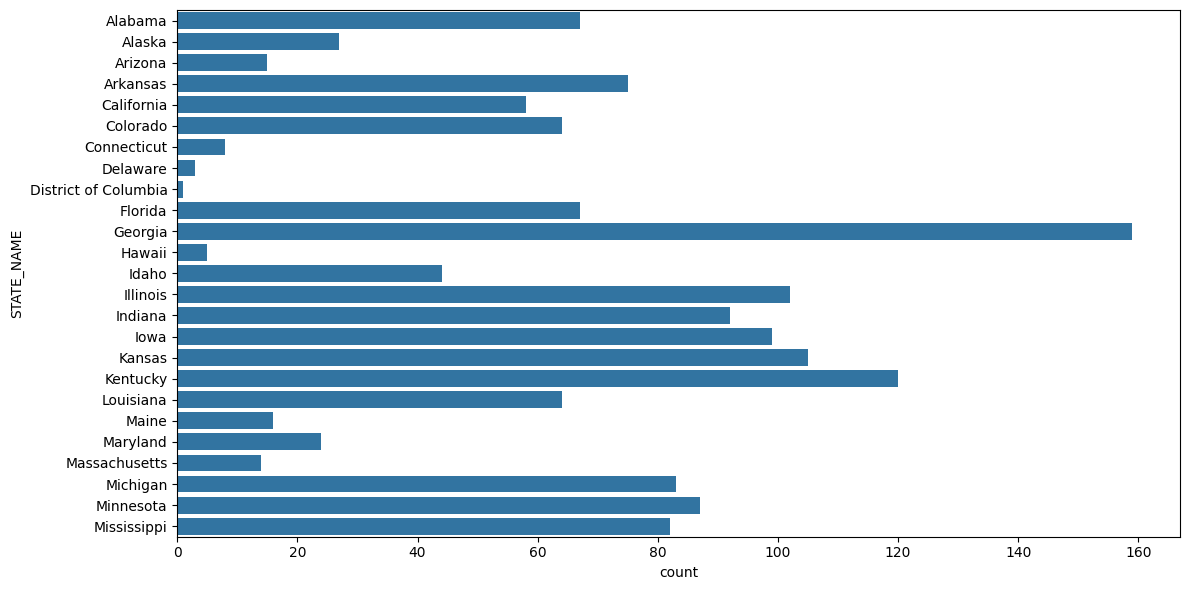

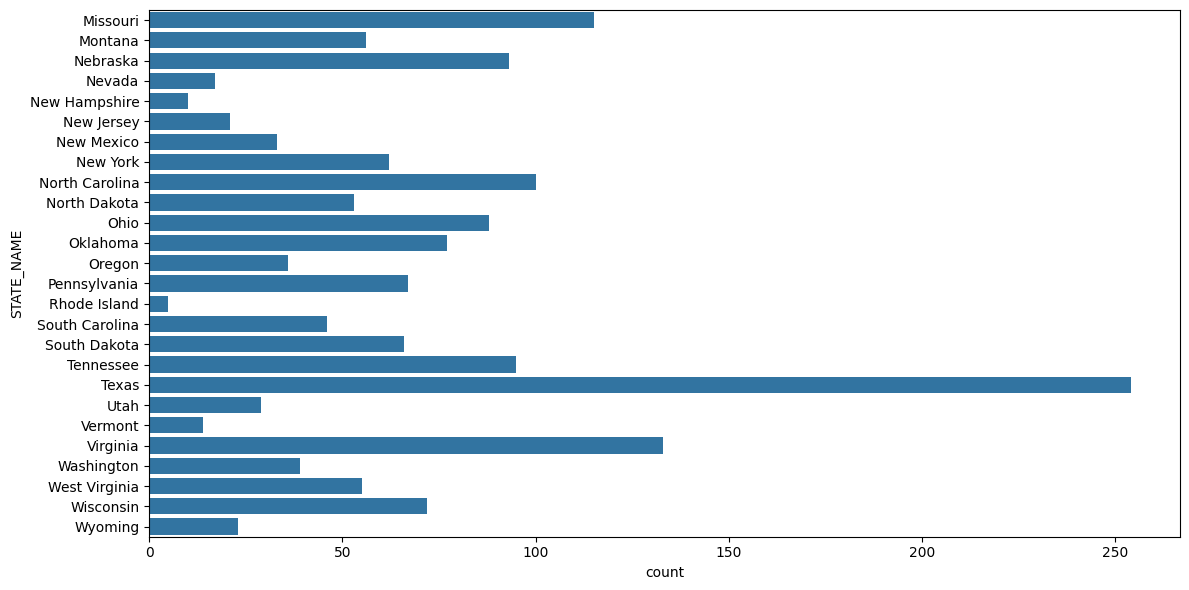

In [15]:
# Lista de todos los estados
states = df['STATE_NAME'].unique()

# Dividir en dos mitades 
mid = len(states) // 2
states_part1 = states[:mid]
states_part2 = states[mid:]

# Graficar la primera parte por orden alfabetico
plt.figure(figsize=(12,6))
sns.countplot(y='STATE_NAME', data=df[df['STATE_NAME'].isin(states_part1)])
plt.tight_layout()

# Graficar la segunda parte por orden alfabetico
plt.figure(figsize=(12,6))
sns.countplot(y='STATE_NAME', data=df[df['STATE_NAME'].isin(states_part2)])
plt.tight_layout()


#### Análisis de Variables Univariantes Numéricas

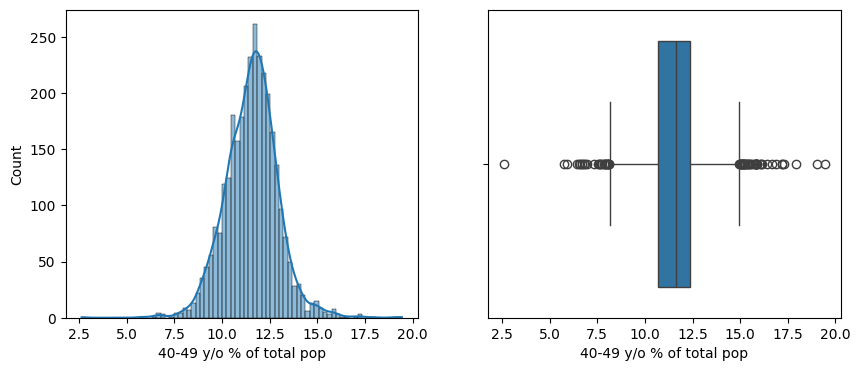

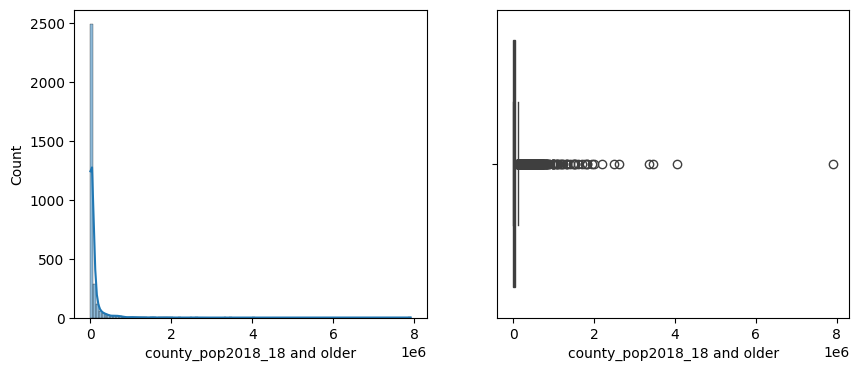

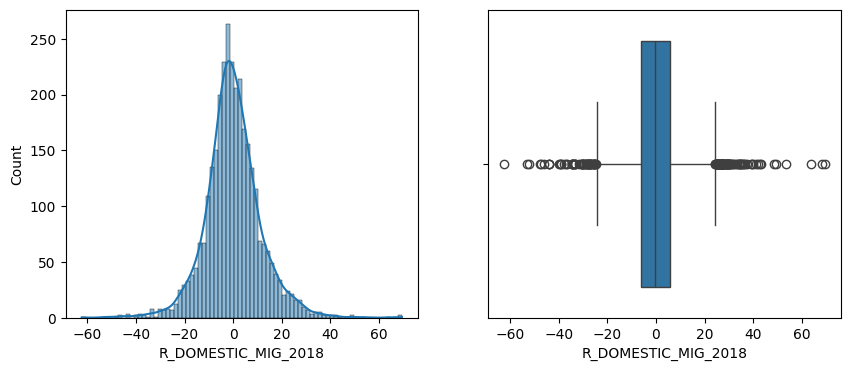

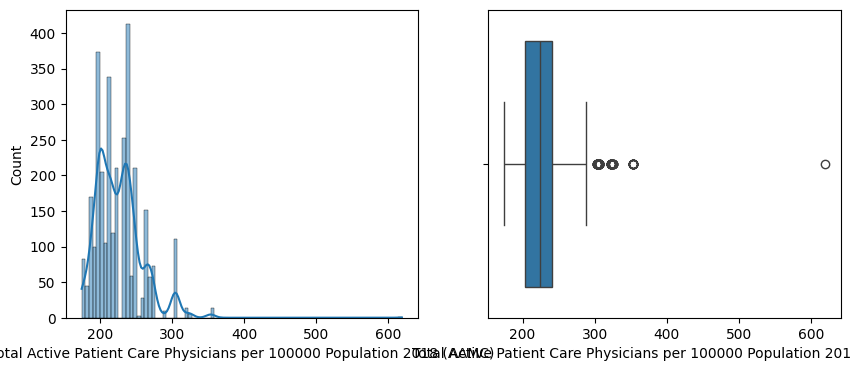

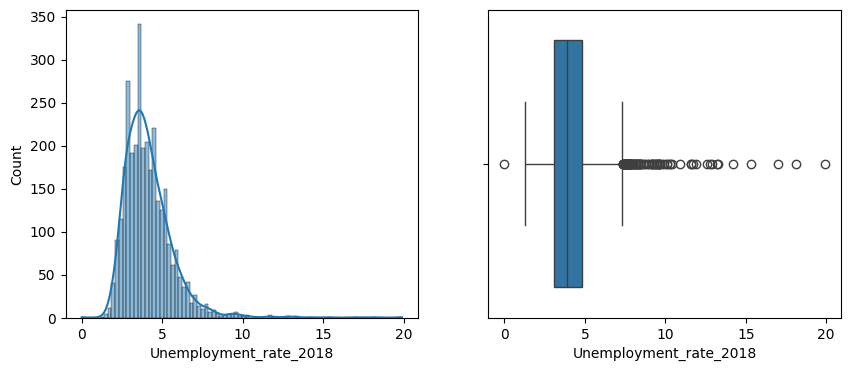

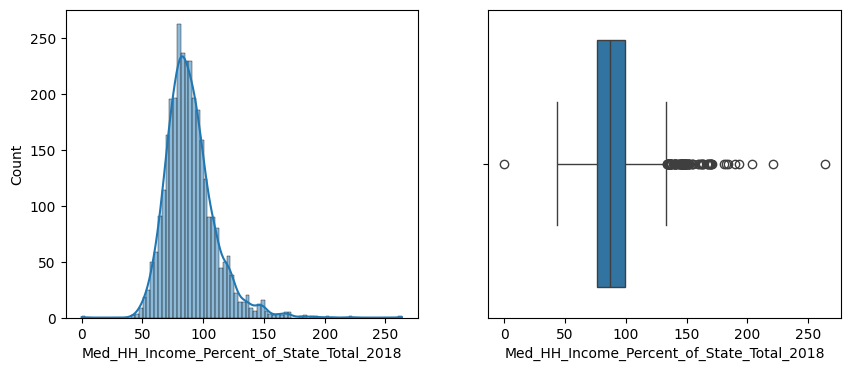

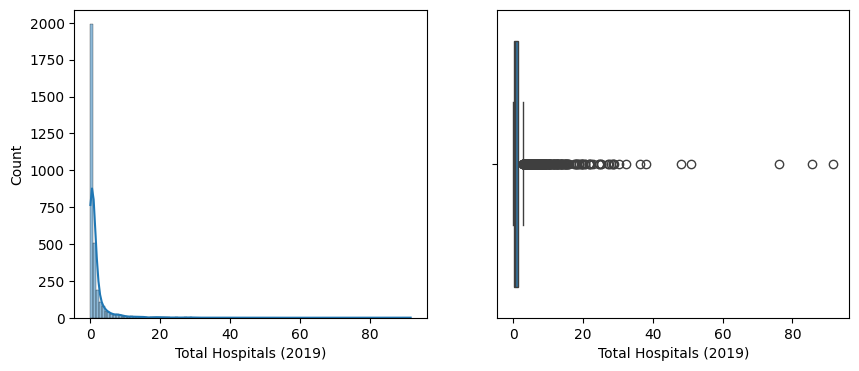

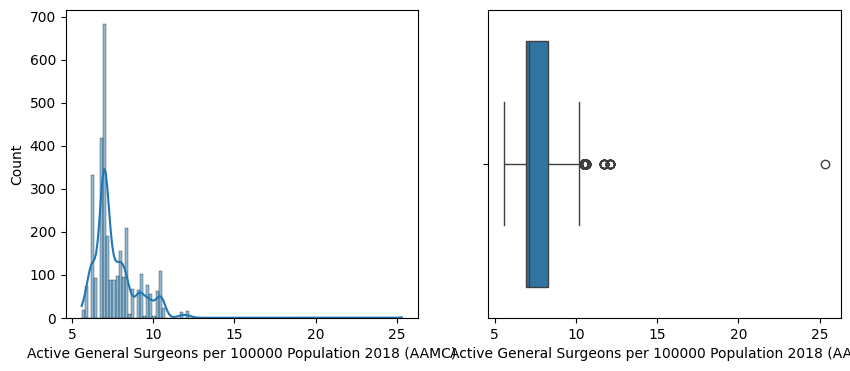

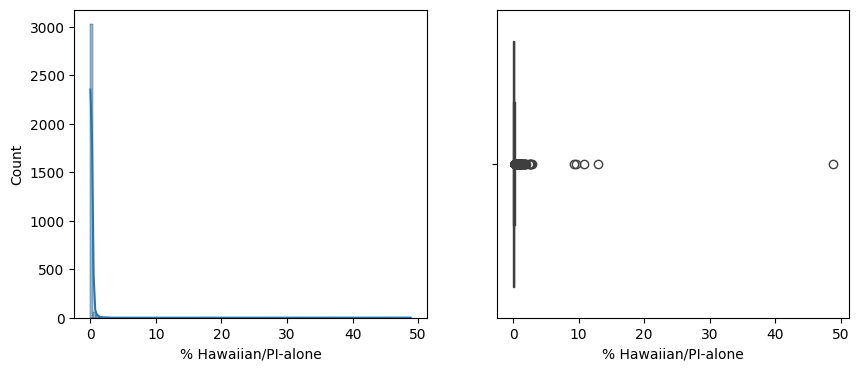

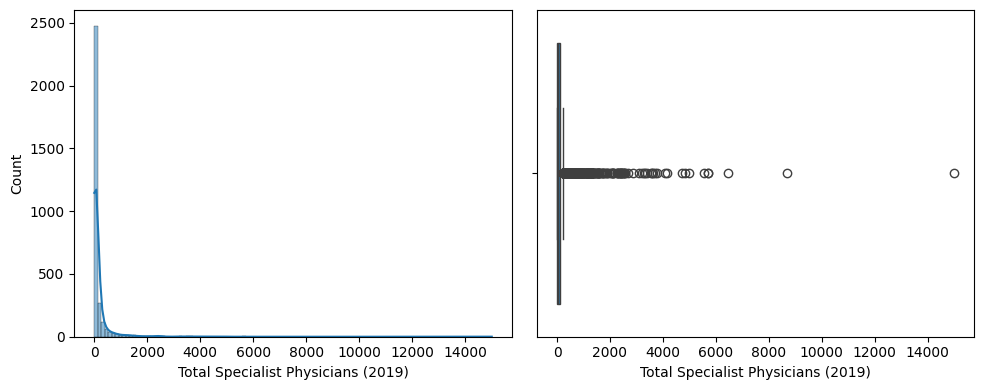

In [16]:
cols_numericas = [col for col in df.columns if col != 'STATE_NAME']  # Guardamos en una variables todas las columnas numéricas
random_cols = random.sample(cols_numericas, 10)  # Graficamos 10 variables numéricas aleatorias, ya que son muchas para visualizarlas todas

for col in random_cols:
    plt.figure(figsize=(10, 4)) 

    plt.subplot(1, 2, 1) 
    sns.histplot(data=df, x=col, kde=True)

    plt.subplot(1, 2, 2)  
    sns.boxplot(data=df, x=col)

plt.tight_layout()

#### Análisis de Variables Multivariante (numerico-numerico)

In [17]:
cols_numericas_sin_target = [col for col in df.columns if col != 'STATE_NAME' and col != 'Heart disease_prevalence']
# Calculamos las 10 variables que tienen mayor correlacion con el target
correlaciones = df[cols_numericas_sin_target].corrwith(df['Heart disease_prevalence']).abs()
top_10_corr = correlaciones.sort_values(ascending=False).head(10)
top_10_corr_list = top_10_corr.index.tolist()
top_10_corr_list

['CKD_prevalence',
 'COPD_prevalence',
 'diabetes_prevalence',
 'anycondition_prevalence',
 'CI90LBINC_2018',
 'MEDHHINC_2018',
 'Median_Household_Income_2018',
 'CI90UBINC_2018',
 "Percent of adults with a bachelor's degree or higher 2014-18",
 'R_death_2018']

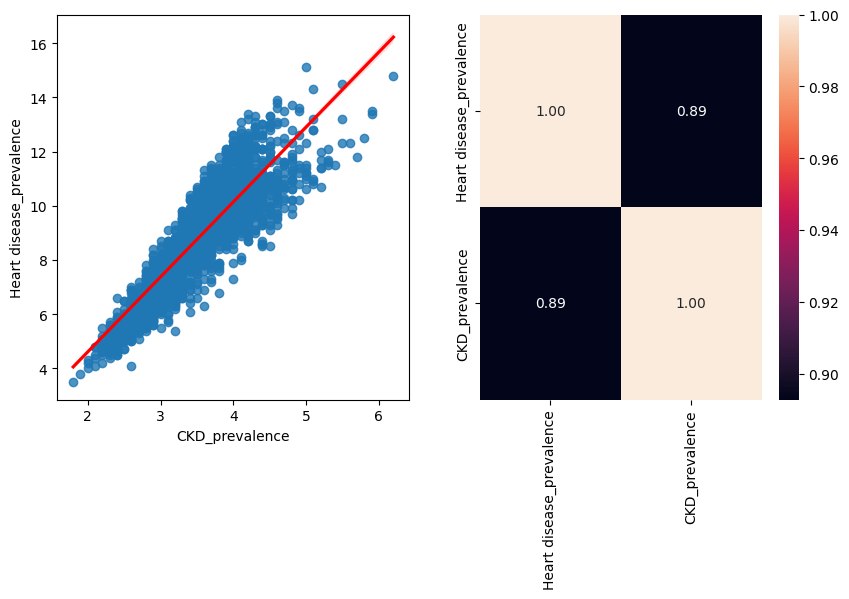

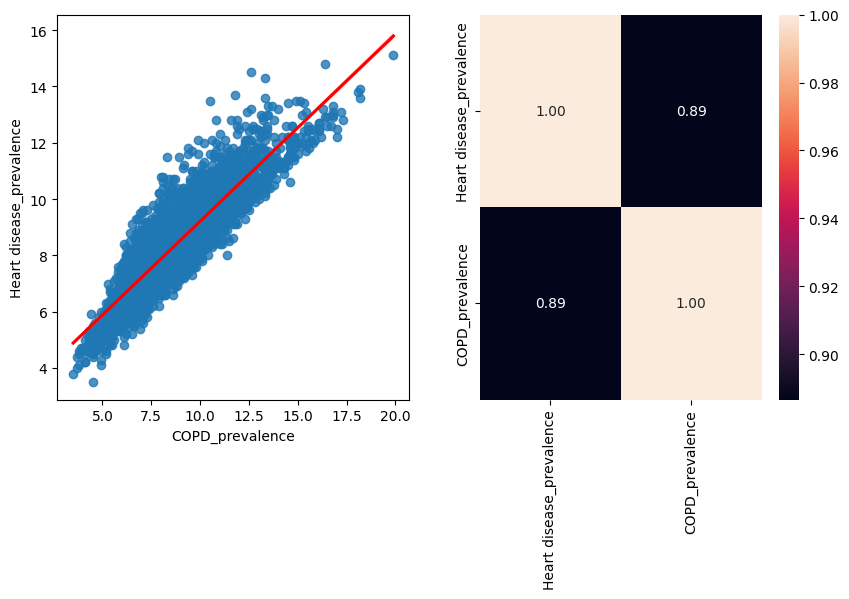

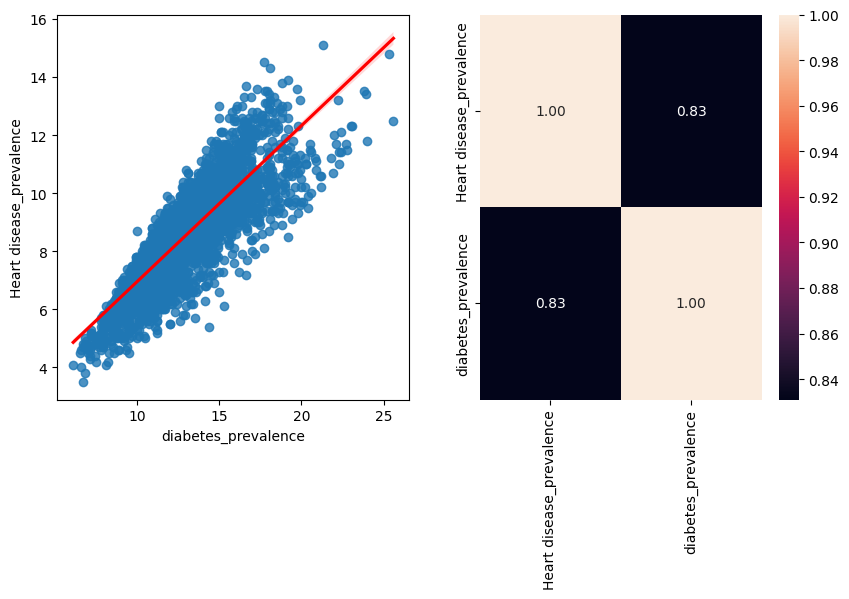

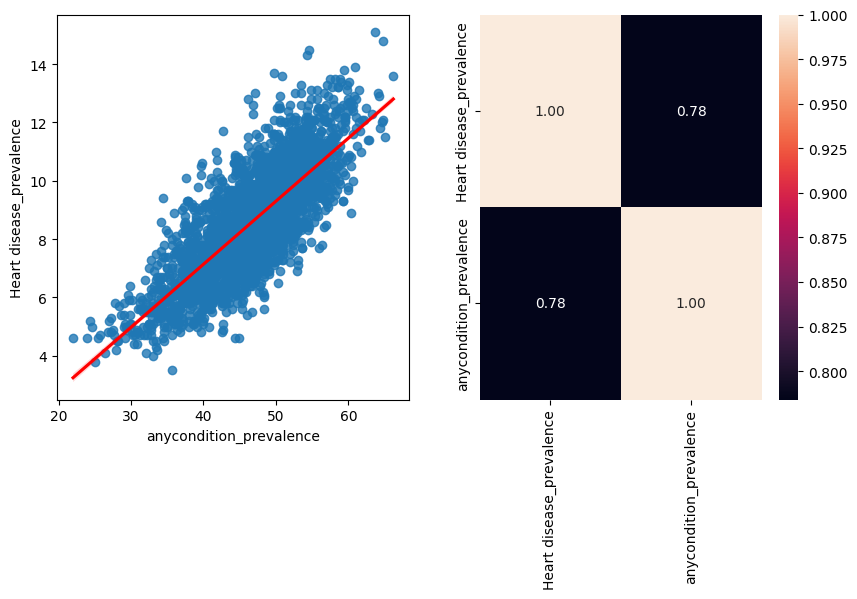

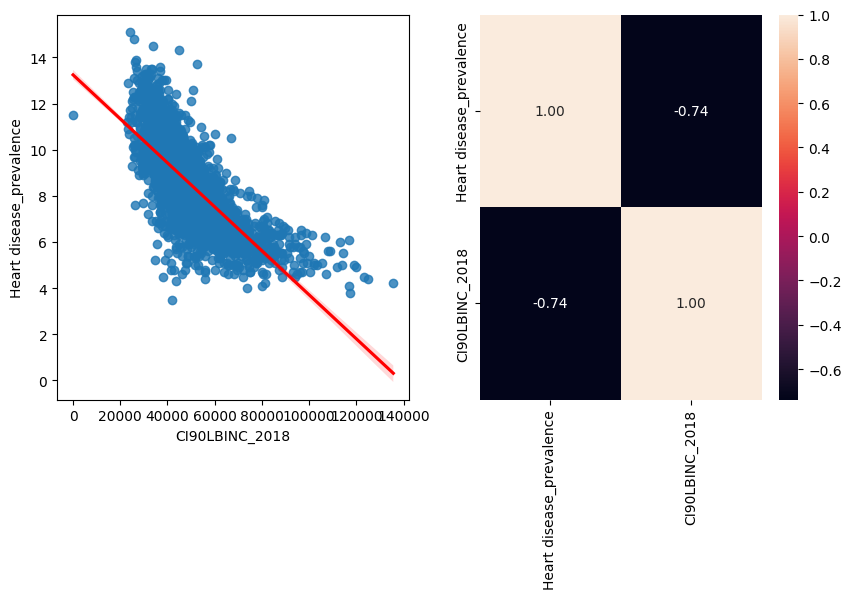

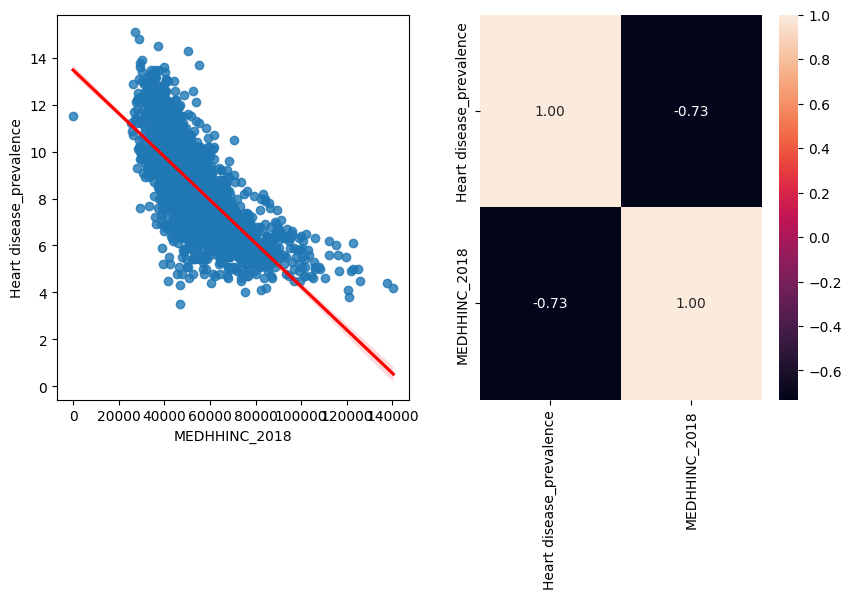

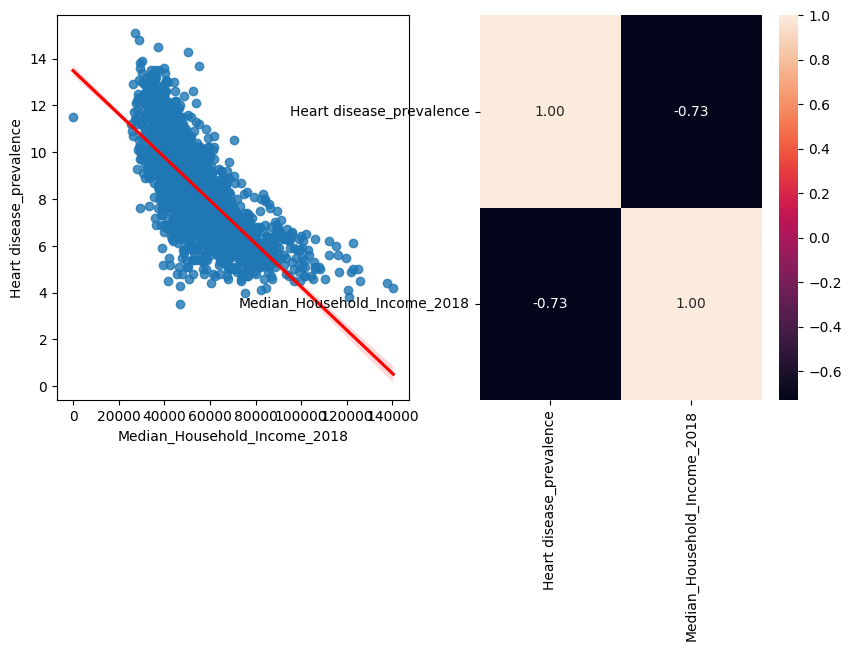

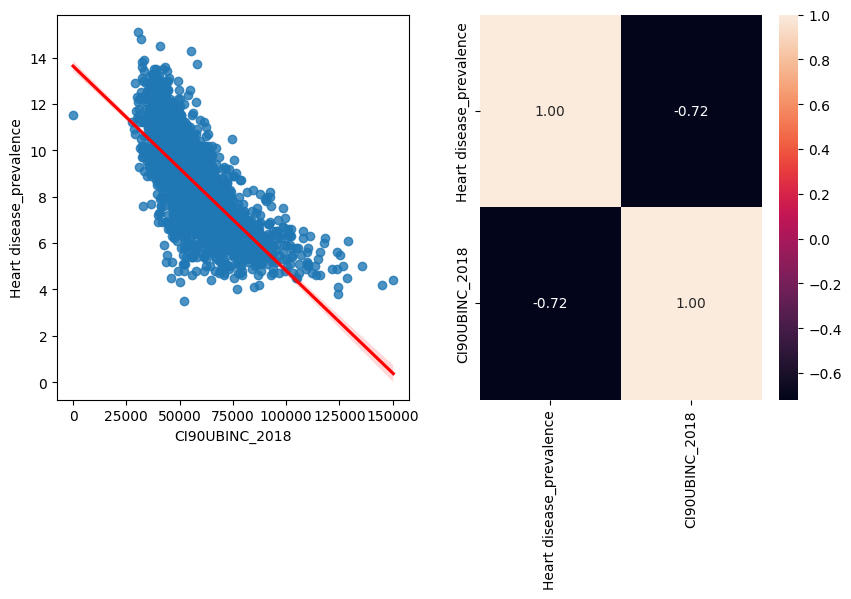

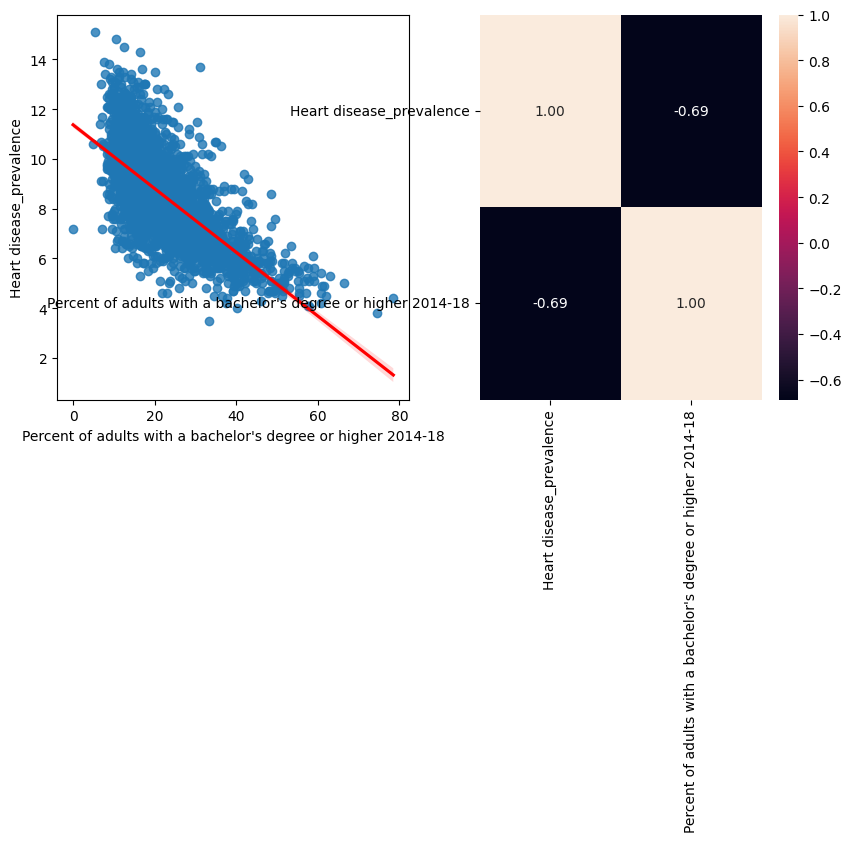

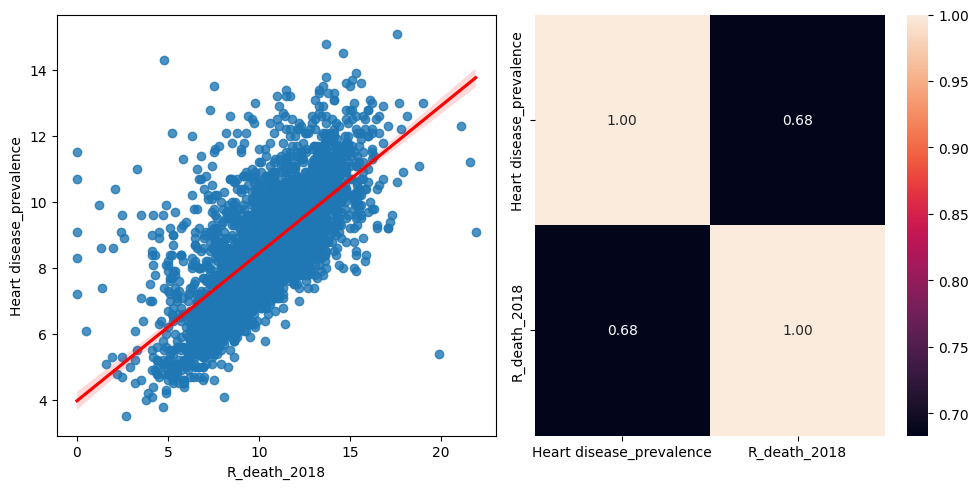

In [14]:
for col in top_10_corr_list:
    plt.figure(figsize=(10, 5)) 

    plt.subplot(1, 2, 1) 
    sns.regplot(data=df, x=col, y='Heart disease_prevalence', line_kws={'color': 'red'})

    plt.subplot(1, 2, 2)  
    sns.heatmap(df[['Heart disease_prevalence', col]].corr(), annot=True, fmt='.2f')

plt.tight_layout()

#### Análisis numérico-categórico (completo)

<Axes: >

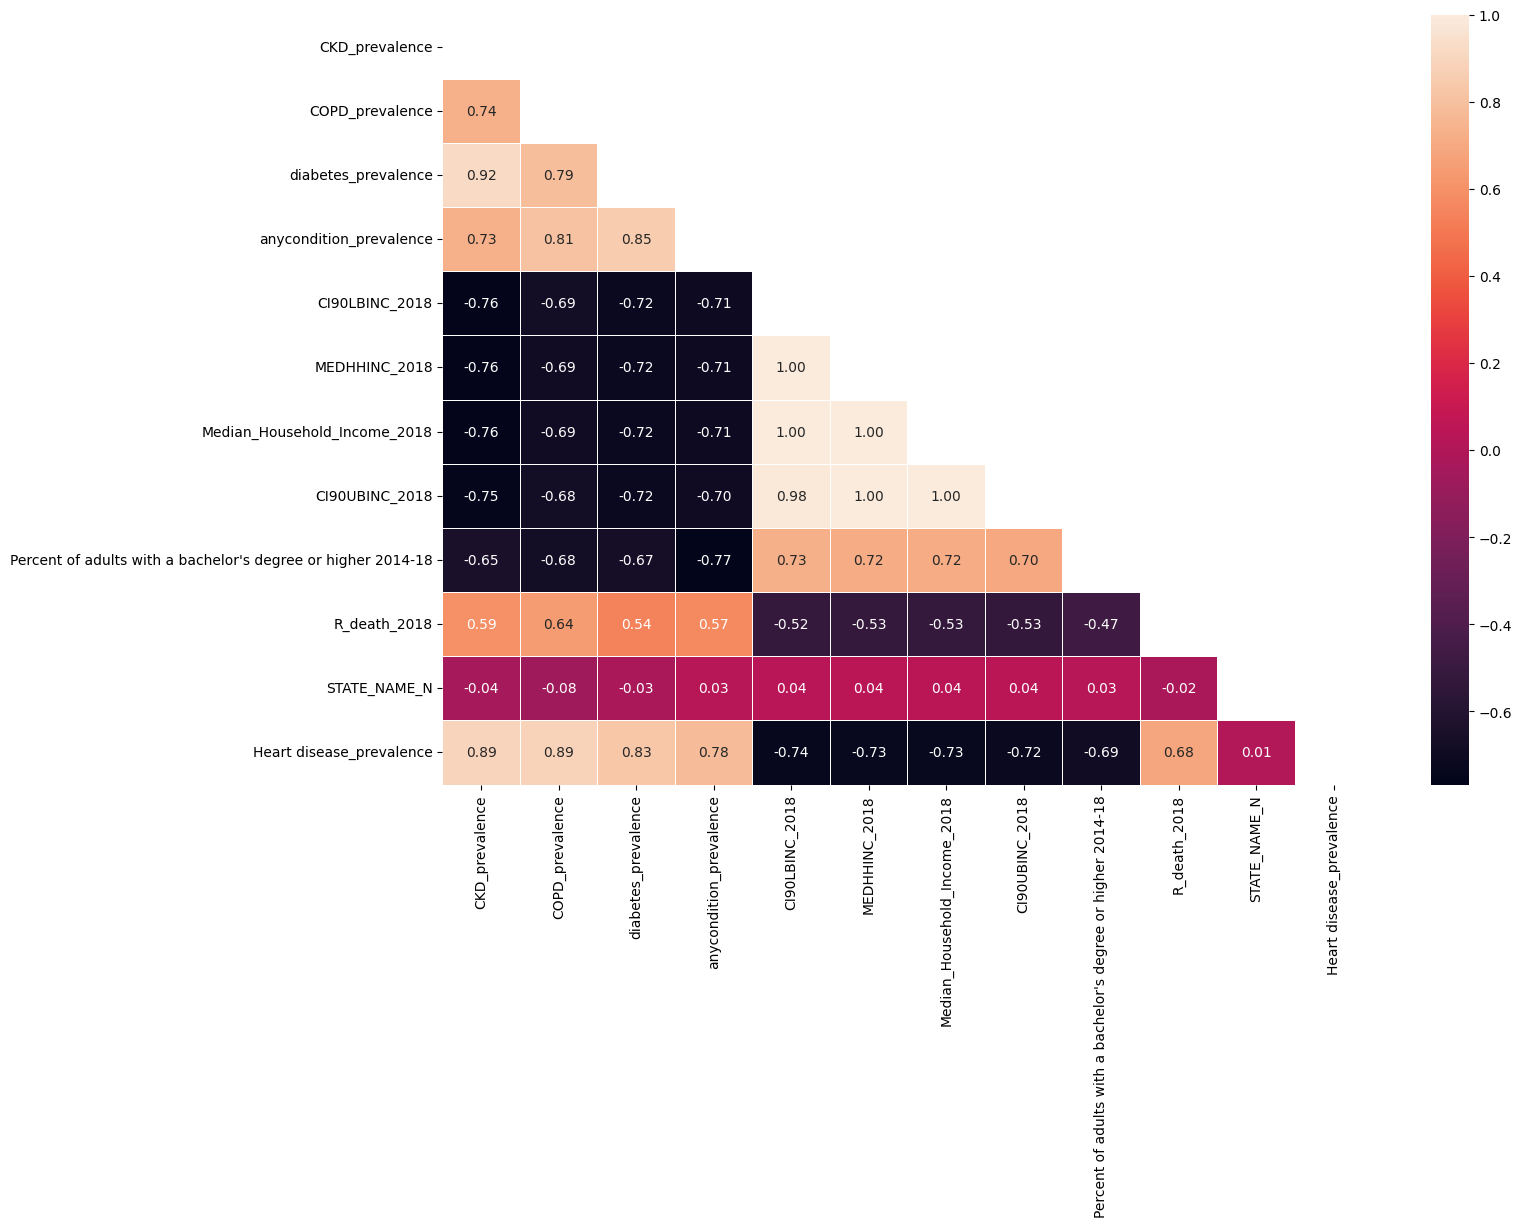

In [18]:
# Creo la columna numérica para la unica variable categórica y la añado junto al target a la lista 'top_10_corr_list', lo guardamos en una nueva lista 'num_var_rest'
df['STATE_NAME_N'] = pd.factorize(df['STATE_NAME'])[0]
num_var_best = top_10_corr_list + ['STATE_NAME_N', 'Heart disease_prevalence']

corr = df[num_var_best].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt='.2f')


> ## Observaciones:
>
> - En el gráfico podemos observar las 10 variables predictoras con mayor correlación con el target 
> - También tenemos la correlación de la única variable predictora categórica (`STATE NAME`) con el target, como podemos ver no hay ninguna relación entre ellas (0,01)

### Ingeniería de características

#### Análisis de outliers

In [19]:
num_var_best

['CKD_prevalence',
 'COPD_prevalence',
 'diabetes_prevalence',
 'anycondition_prevalence',
 'CI90LBINC_2018',
 'MEDHHINC_2018',
 'Median_Household_Income_2018',
 'CI90UBINC_2018',
 "Percent of adults with a bachelor's degree or higher 2014-18",
 'R_death_2018',
 'STATE_NAME_N',
 'Heart disease_prevalence']

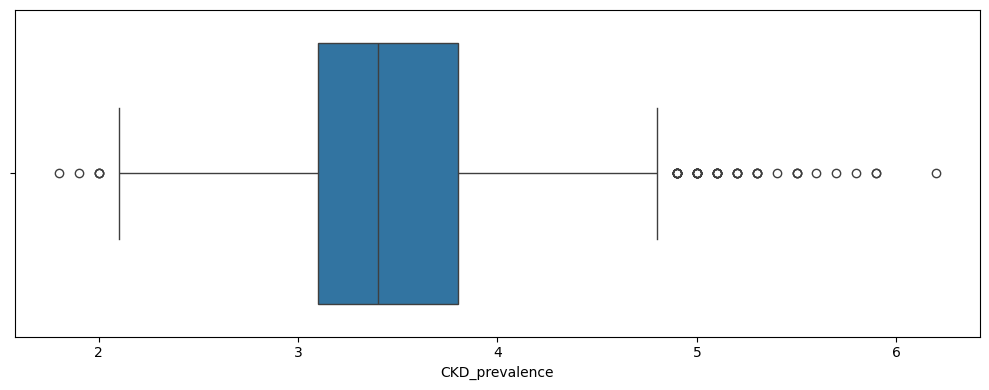

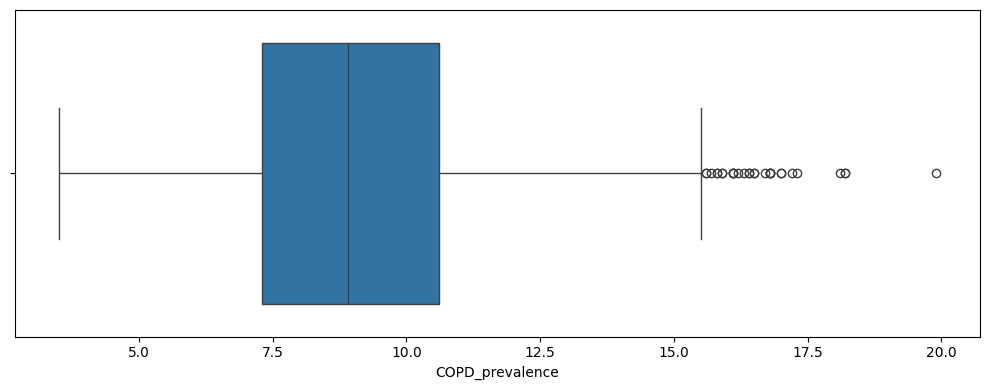

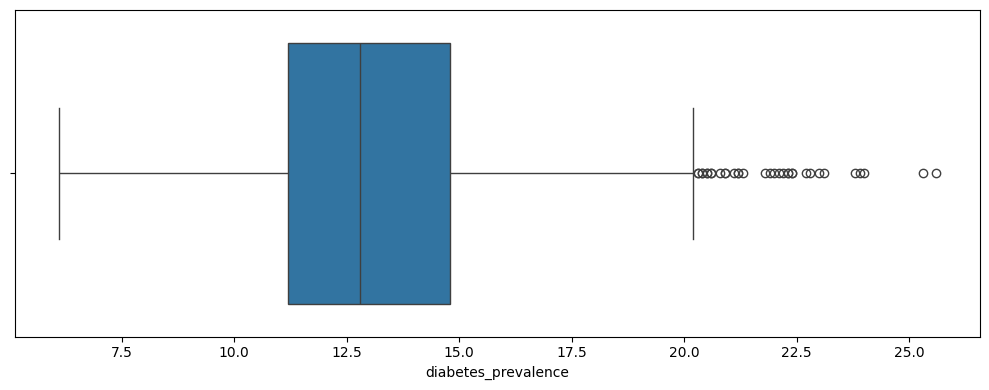

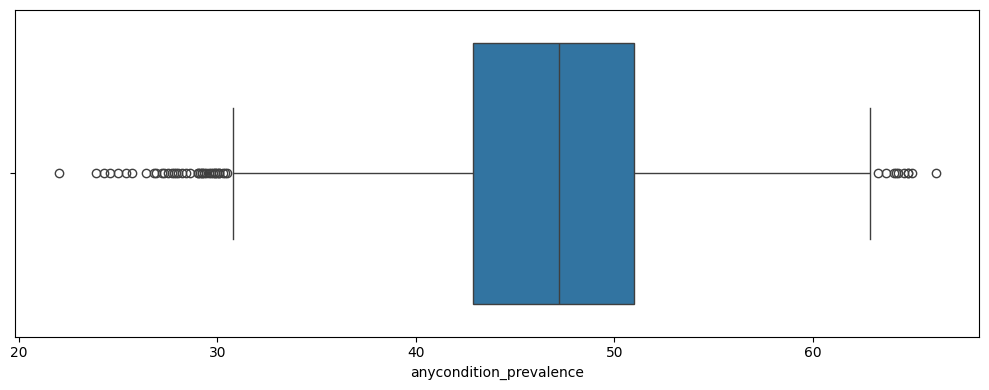

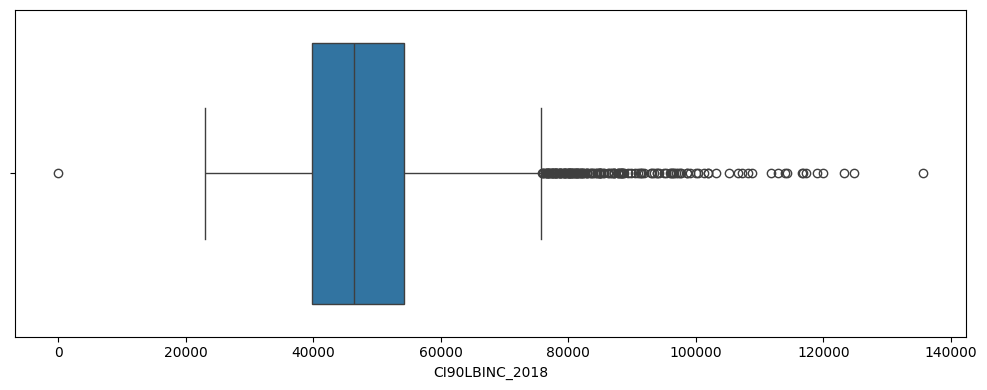

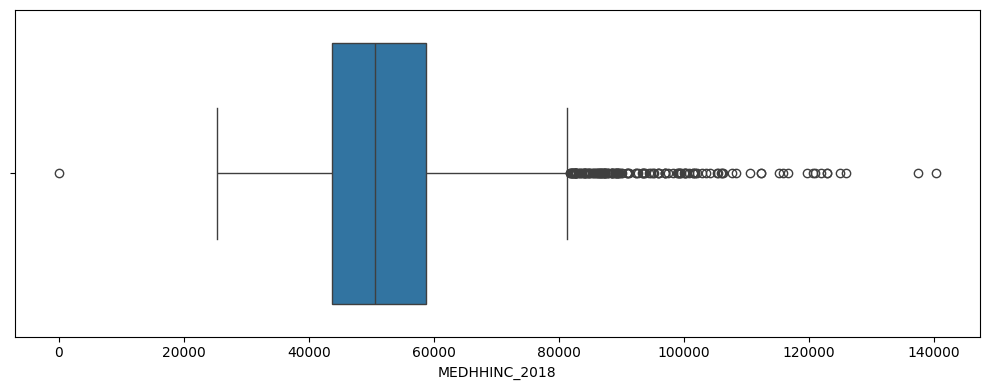

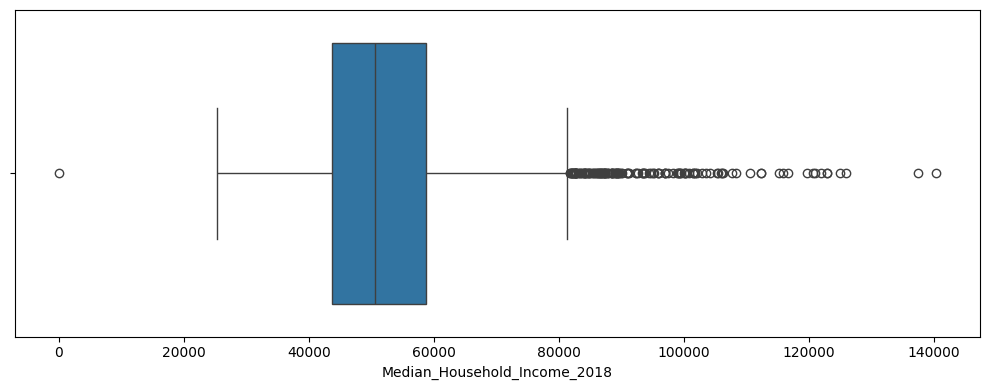

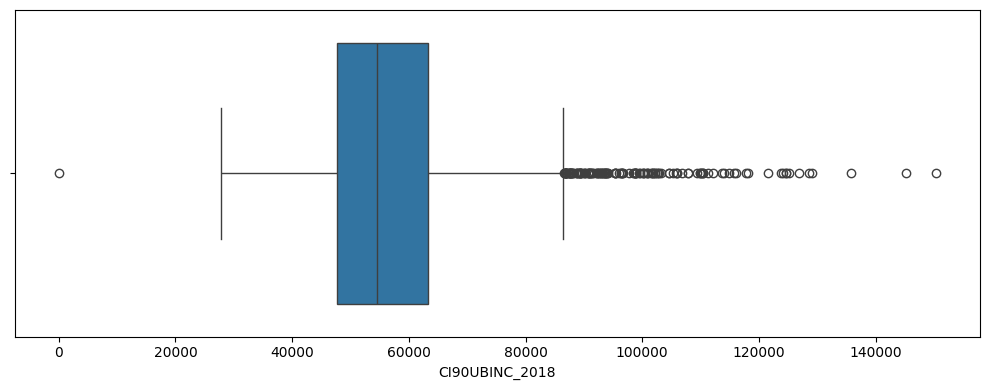

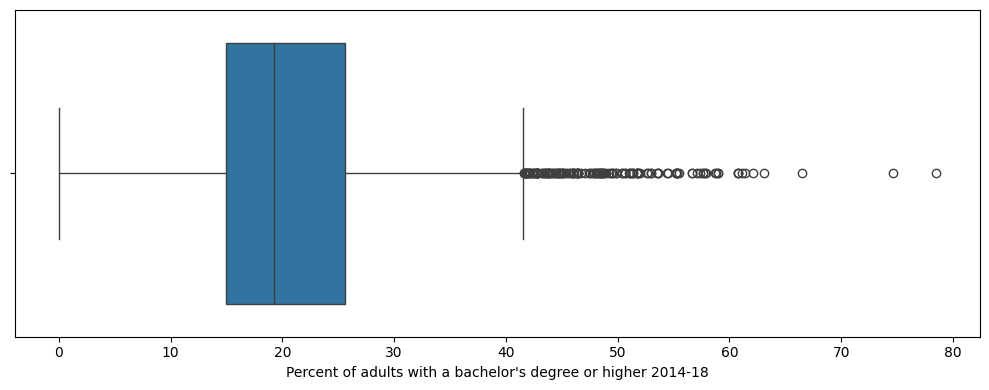

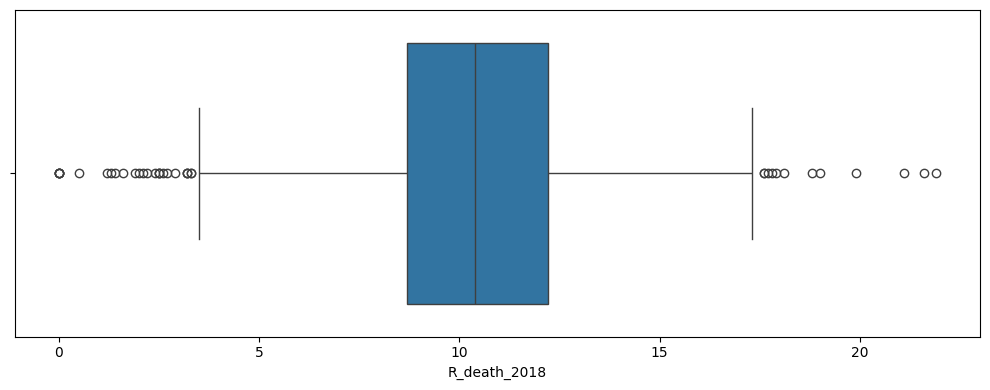

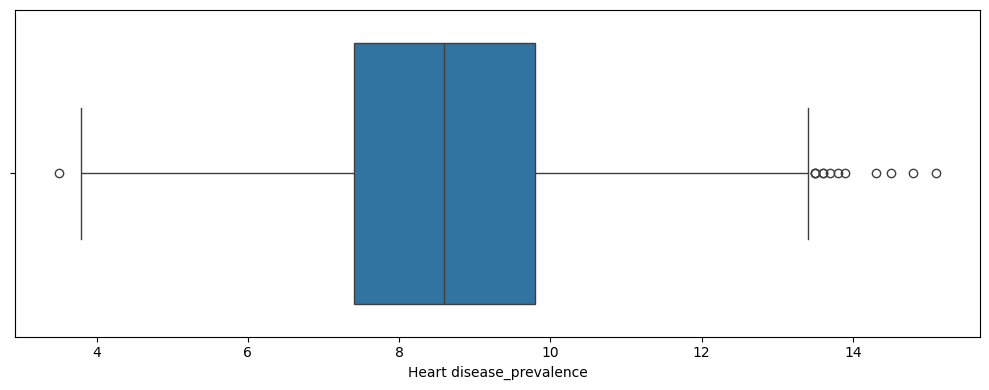

In [20]:
# Eliminamos la variable STATE_NAME_N ya que hemos visto que no tiene nada de relacion con el target
num_var_best.remove('STATE_NAME_N')

for col in num_var_best:
    plt.figure(figsize=(10, 4)) 
    
    sns.boxplot(data=df, x=col)

    plt.tight_layout()


> ## Observaciones:
>
> - Todas las variables con mejor correlacion con el target tienen outliers
> - De momento vamos a conservar todos los outliers

#### Análisis de valores faltantes

In [21]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

> ## Observaciones:
> - No existen valores nulos

#### Inferencia de nuevas características

In [22]:
df.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code,STATE_NAME_N
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Autauga,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,...,1,42438,47.6,35.8,7.9,8.6,12.9,3.1,3,0
Baldwin,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,...,3,170912,40.2,29.7,7.8,8.6,12.0,3.2,4,0
Barbour,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,...,5,19689,57.5,40.7,11.0,12.1,19.7,4.5,6,0
Bibb,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,...,7,17813,51.6,38.7,8.6,10.0,14.1,3.3,2,0
Blount,1009,57840,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,...,9,44448,46.3,34.0,9.2,10.5,13.5,3.4,2,0


> ## Observaciones 
> 
> - No encontramos relación para crear una variable a partir de la fusion de varias

### Split (Segundo Enfoque)

In [27]:
X = df.drop('Heart disease_prevalence', axis= 1)
y = df['Heart disease_prevalence']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
X_train

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code,STATE_NAME_N
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Osage,29151,13714,12.016917,13.934665,11.674202,11.258568,12.308590,14.671139,11.973166,7.583491,...,29,151,10543,43.2,31.4,8.8,10.8,2.9,4,25
Wise,48497,68305,13.083962,14.082424,11.555523,12.715028,12.634507,14.425005,11.455970,7.053656,...,48,497,51386,50.9,39.5,8.3,12.3,3.1,2,43
Livingston,36051,63227,9.114777,13.495817,15.623072,10.756481,11.063312,14.818037,13.105161,7.566388,...,36,51,52072,42.5,35.4,8.6,10.7,3.0,2,32
Calhoun,28013,14436,11.907731,13.563314,11.450540,11.041840,12.371848,13.791909,13.071488,7.931560,...,28,13,11060,57.5,38.1,11.7,16.7,4.1,6,24
Saline,29195,22895,12.094344,13.968115,13.430880,11.657567,11.107229,12.810657,12.015724,7.975541,...,29,195,17775,50.2,36.8,10.1,12.8,3.4,5,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mobile,1097,413757,12.907818,12.945038,13.869977,12.820085,11.746508,13.018994,11.894421,7.174501,...,1,97,317046,48.9,36.9,9.1,14.4,3.5,3,0
Switzerland,18155,10717,13.417934,13.483251,10.627974,11.626388,12.382197,14.528319,12.242232,7.772698,...,18,155,8072,52.3,40.4,12.2,14.9,3.5,6,14
Jefferson,36045,111755,14.597110,11.769496,19.365576,14.248132,10.029976,11.119860,9.590622,5.941569,...,36,45,84957,45.3,37.1,7.9,9.6,2.7,4,32


### Scaling - Escalado Mínimo-Máximo (variables numéricas)

In [31]:
len(cols_numericas_sin_target)

68

In [32]:
min_max_scaler = MinMaxScaler()
# Ajustamos solo con los datos de entrenamiento
min_max_scaler.fit(X_train[cols_numericas_sin_target])

X_train_scal = min_max_scaler.transform(X_train[cols_numericas_sin_target])
X_train_scal = pd.DataFrame(X_train_scal, index=X_train.index, columns=cols_numericas_sin_target)

X_test_scal = min_max_scaler.transform(X_test[cols_numericas_sin_target])
X_test_scal = pd.DataFrame(X_test_scal, index=X_test.index, columns=cols_numericas_sin_target)

X_train_scal.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,Percent of Population Aged 60+,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Osage,0.511409,0.001348,0.471979,0.597942,0.310730,0.320213,0.576054,0.617959,0.357925,0.184835,...,0.280822,0.509091,0.178784,0.001321,0.479638,0.466859,0.314815,0.241026,0.250000,0.6
Wise,0.862873,0.006751,0.513889,0.604283,0.307572,0.410495,0.595455,0.601700,0.336220,0.166645,...,0.253425,0.854545,0.591180,0.006480,0.653846,0.700288,0.283951,0.317949,0.295455,0.2
Livingston,0.636763,0.006248,0.357994,0.579111,0.415837,0.289090,0.501925,0.627663,0.405432,0.184248,...,0.296233,0.636364,0.059595,0.006567,0.463801,0.582133,0.302469,0.235897,0.272727,0.2
Calhoun,0.490735,0.001420,0.467691,0.582007,0.304777,0.306778,0.579820,0.559879,0.404019,0.196784,...,0.337329,0.490909,0.014303,0.001386,0.803167,0.659942,0.493827,0.543590,0.522727,1.0
Saline,0.512208,0.002257,0.475021,0.599377,0.357488,0.344945,0.504539,0.495059,0.359711,0.198294,...,0.301370,0.509091,0.231228,0.002234,0.638009,0.622478,0.395062,0.343590,0.363636,0.8


In [34]:
# Guardamos el scaler utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/lineal-regression-reg-min_max_scaler.pkl', 'wb') as file:
    pickle.dump(min_max_scaler, file)

### Seleccción de Características

In [36]:
len(X_train_scal.columns)

68

In [39]:
# Selecciona las k mejores características
selection_model = SelectKBest(f_regression, k=30)
selection_model.fit(X_train_scal, y_train)
bool_variables = selection_model.get_support()

X_train_sel = selection_model.transform(X_train_scal)
X_train_sel = pd.DataFrame(X_train_sel, index=X_train_scal.index, columns=X_train_scal.columns.values[bool_variables])

X_test_sel = selection_model.transform(X_test_scal)
X_test_sel = pd.DataFrame(X_test_sel, index=X_test_scal.index, columns=X_test_scal.columns.values[bool_variables])

X_test_sel

,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% Asian-alone,GQ_ESTIMATES_2018,R_death_2018,R_NATURAL_INC_2018,...,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Total Hospitals (2019),Percent of Population Aged 60+,anycondition_prevalence,Obesity_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Durham,0.509226,0.428968,0.646095,0.292039,0.112769,0.126733,0.127883,0.077994,0.319635,0.484337,...,0.422625,0.417299,0.037237,0.195205,0.337104,0.432277,0.141975,0.235897,0.227273,0.4
Fairfield,0.487679,0.304759,0.249890,0.541659,0.250601,0.190715,0.016213,0.002226,0.611872,0.221687,...,0.281532,0.286039,0.003300,0.378425,0.647059,0.746398,0.401235,0.671795,0.613636,0.4
Saline,0.510847,0.307297,0.347575,0.410010,0.226494,0.231908,0.015193,0.004951,0.625571,0.310843,...,0.290358,0.237481,0.003811,0.347603,0.610860,0.593660,0.456790,0.358974,0.454545,1.0
Monona,0.542375,0.268039,0.235841,0.447792,0.261901,0.365526,0.006975,0.001144,0.712329,0.214458,...,0.359946,0.319044,0.003523,0.450342,0.583710,0.605187,0.302469,0.333333,0.431818,1.0
Emporia,0.599958,0.338363,0.342544,0.352889,0.218790,0.301582,0.024550,0.001379,0.657534,-0.016867,...,0.262911,0.192716,0.000614,0.291096,0.773756,0.780980,0.493827,0.728205,0.750000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Dyer,0.579842,0.328574,0.339862,0.348549,0.202758,0.175316,0.018466,0.002893,0.561644,0.330120,...,0.315582,0.320941,0.006898,0.279110,0.660633,0.587896,0.475309,0.441026,0.409091,0.8
King,0.573171,0.269051,0.450314,0.431168,0.135182,0.285921,0.000000,0.000000,0.000000,0.585542,...,0.412624,0.362291,0.000040,0.090753,0.522624,0.512968,0.265432,0.302564,0.318182,1.0
Franklin,0.607218,0.317250,0.359226,0.369904,0.177773,0.169264,0.012172,0.002686,0.442922,0.363855,...,0.413393,0.378604,0.013328,0.273973,0.590498,0.648415,0.253086,0.282051,0.250000,0.8


In [40]:
# Guardamos el slection_model utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/lineal-regression-reg-selection-model.pkl', 'wb') as file:
    pickle.dump(selection_model, file)

> ## Conclusiones
>
> EDA terminado, ya tenemos nuetro conjuntos de datos de entrenamientos y de prueba para empezar a construir el modelo:
> - `X_train_sel`, `X_test_sel` ,`y_train` , `y_test`

## Paso 4: Construimos un modelo de regresión lineal